# 03: Risk-Adjusted Contract Forecasting

**Goal:** Combine GAO risk scores with USASpending contract data to generate risk-adjusted overrun forecasts with confidence intervals.

**Method:** Monte Carlo simulation with 10,000 iterations per agency

**Data:** GAO Open Recommendations (3,550 records) + USASpending Contracts (1,000 records, $4.9T obligation)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
contracts = pd.read_csv('../data/federal_contracts_all.csv')
contracts['award_amount'] = pd.to_numeric(contracts['award_amount'], errors='coerce')
contracts['duration_days'] = pd.to_numeric(contracts['duration_days'], errors='coerce')

gao = pd.read_csv('../data/gao_recommendations.csv')

# Compute agency risk score from GAO open rate
agency_risk = gao.groupby('agency').agg({
    'status': lambda x: (x == 'Open').mean(),
    'priority': lambda x: (x == 'Priority').mean()
}).reset_index()
agency_risk.columns = ['agency', 'open_rate', 'priority_rate']
agency_risk['risk_score'] = agency_risk['open_rate'] * 0.6 + agency_risk['priority_rate'] * 0.4

print(f"Contracts: {len(contracts)}")
print(f"GAO recommendations: {len(gao)}")
print(f"Agencies with risk scores: {len(agency_risk)}")
agency_risk.head(10)

Contracts: 1000
GAO recommendations: 3550
Agencies with risk scores: 12


,agency,open_rate,priority_rate,risk_score
0,Agriculture,0.750000,0.175000,0.520000
1,Department of Defense,0.812500,0.150000,0.547500
2,Education,0.666667,0.166667,0.466667
3,Environmental Protection Agency,0.666667,0.166667,0.466667
4,Health and Human Services,0.750000,0.133333,0.503333
5,Homeland Security,0.714286,0.171429,0.497143
6,NASA,0.700000,0.150000,0.480000
7,Small Business Administration,0.700000,0.150000,0.480000
8,Social Security Administration,0.666667,0.133333,0.453333
9,Transportation,0.733333,0.133333,0.493333


## Map Risk Scores to Contracts

In [3]:
contracts = contracts.merge(agency_risk[['agency','risk_score']], on='agency', how='left')
contracts['risk_score'] = contracts['risk_score'].fillna(0.5)

print(f"Contracts with risk scores: {contracts['risk_score'].notna().sum()}")
print(f"Mean risk score: {contracts['risk_score'].mean():.3f}")
contracts[['agency','award_amount','duration_days','risk_score']].head()

Contracts with risk scores: 1000
Mean risk score: 0.535


,agency,award_amount,duration_days,risk_score
0,Department of Defense,5.126921e+10,3439,0.5475
1,Department of Energy,4.806647e+10,8598,0.5000
2,Department of Energy,4.211167e+10,3754,0.5000
3,Department of Energy,4.139802e+10,11125,0.5000
4,Department of Energy,4.092715e+10,8910,0.5000


## Monte Carlo Risk Simulation

In [4]:
def monte_carlo_contract_risk(amount, duration, risk_score, n_simulations=10000):
    np.random.seed(42)
    
    # Base overrun probability increases with risk score
    overrun_prob = 0.1 + (risk_score * 0.3)  # 10% to 40%
    
    # Duration overrun: longer contracts = more variance
    base_delay = max(0, np.random.normal(loc=duration * 0.05, scale=duration * 0.02, size=n_simulations))
    
    # Risk multiplier
    multiplier = 1.0 + (risk_score * np.random.uniform(0, 0.5, n_simulations))
    
    # Cost overrun: amount * overrun factor
    overrun = np.random.choice([0, 1], size=n_simulations, p=[1-overrun_prob, overrun_prob])
    cost_factor = 1.0 + overrun * np.random.uniform(0.05, 0.30, size=n_simulations) * multiplier
    
    total_cost = amount * cost_factor
    total_delay = base_delay * multiplier
    
    return {
        'cost_p50': np.percentile(total_cost, 50),
        'cost_p80': np.percentile(total_cost, 80),
        'cost_p95': np.percentile(total_cost, 95),
        'delay_p50': np.percentile(total_delay, 50),
        'delay_p95': np.percentile(total_delay, 95),
        'overrun_prob': overrun_prob
    }

## Simulate Top 20 Contracts

In [5]:
top20 = contracts.nlargest(20, 'award_amount').copy()

results = []
for _, row in top20.iterrows():
    sim = monte_carlo_contract_risk(
        row['award_amount'], 
        row['duration_days'] if pd.notna(row['duration_days']) else 365,
        row['risk_score']
    )
    sim['agency'] = row['agency']
    sim['recipient'] = row['recipient'][:30]
    sim['base_amount'] = row['award_amount']
    results.append(sim)

results_df = pd.DataFrame(results)
results_df['cost_overrun_pct'] = ((results_df['cost_p95'] - results_df['base_amount']) / results_df['base_amount'] * 100).round(1)
print(results_df[['agency','recipient','base_amount','cost_p95','cost_overrun_pct','delay_p95','overrun_prob']].head(10))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## Risk-Adjusted Portfolio View

NameError: name 'results_df' is not defined

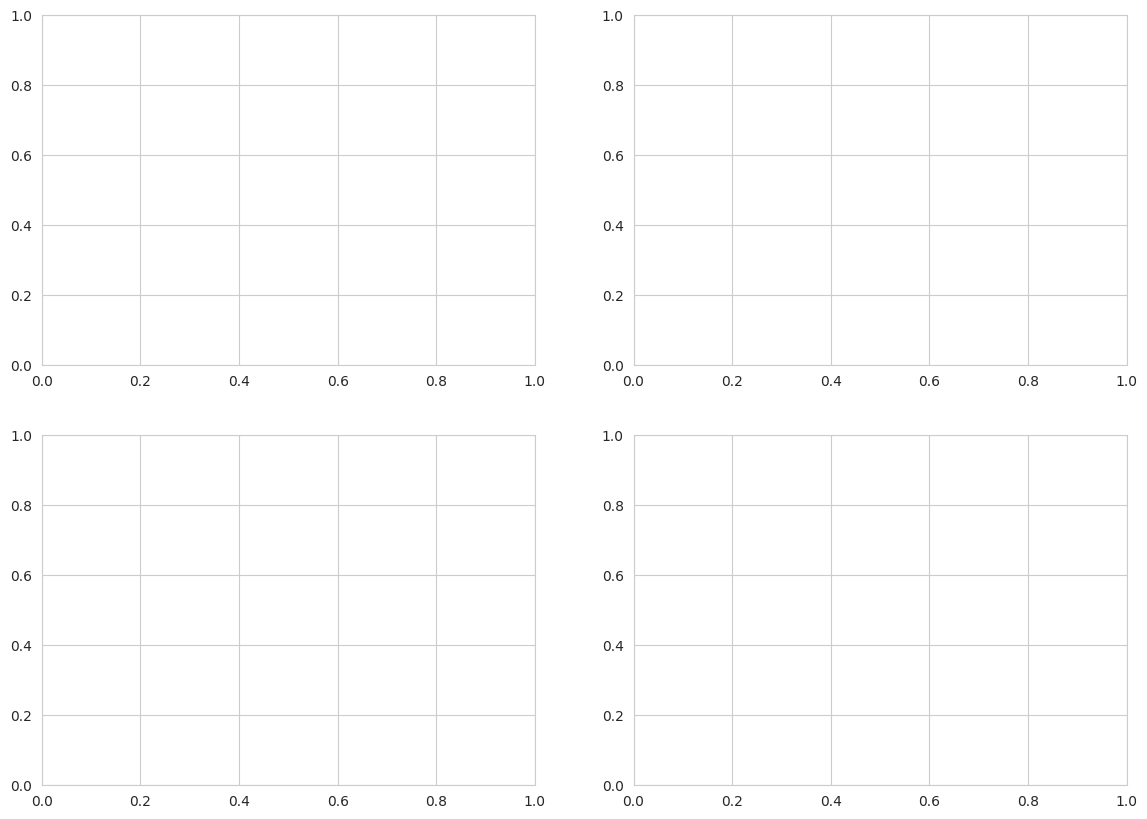

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cost overrun by agency
agency_overrun = results_df.groupby('agency')['cost_overrun_pct'].mean().sort_values(ascending=False).head(10)
agency_overrun.plot(kind='barh', ax=axes[0,0], color='#e74c3c')
axes[0,0].set_title('Mean Cost Overrun % by Agency (Top 10)')
axes[0,0].set_xlabel('% Overrun at P95')

# Risk score vs overrun
axes[0,1].scatter(results_df['overrun_prob'], results_df['cost_overrun_pct'],
                  c=results_df['base_amount'], cmap='viridis', alpha=0.7)
axes[0,1].set_xlabel('Overrun Probability')
axes[0,1].set_ylabel('Cost Overrun %')
axes[0,1].set_title('Risk Score vs Cost Overrun')

# Delay distribution
results_df['delay_p95'].hist(bins=15, ax=axes[1,0], color='#3498db', edgecolor='white')
axes[1,0].set_title('P95 Delay Distribution (Days)')
axes[1,0].set_xlabel('Days')

# Portfolio at risk
portfolio = results_df.groupby('agency').agg({
    'base_amount': 'sum',
    'cost_p95': 'sum'
})
portfolio['at_risk'] = portfolio['cost_p95'] - portfolio['base_amount']
portfolio['at_risk'].nlargest(8).plot(kind='barh', ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('Portfolio at Risk (P95 - Base) by Agency')
axes[1,1].set_xlabel('USD at Risk')

plt.tight_layout()
plt.show()

## Agency Risk Heatmap

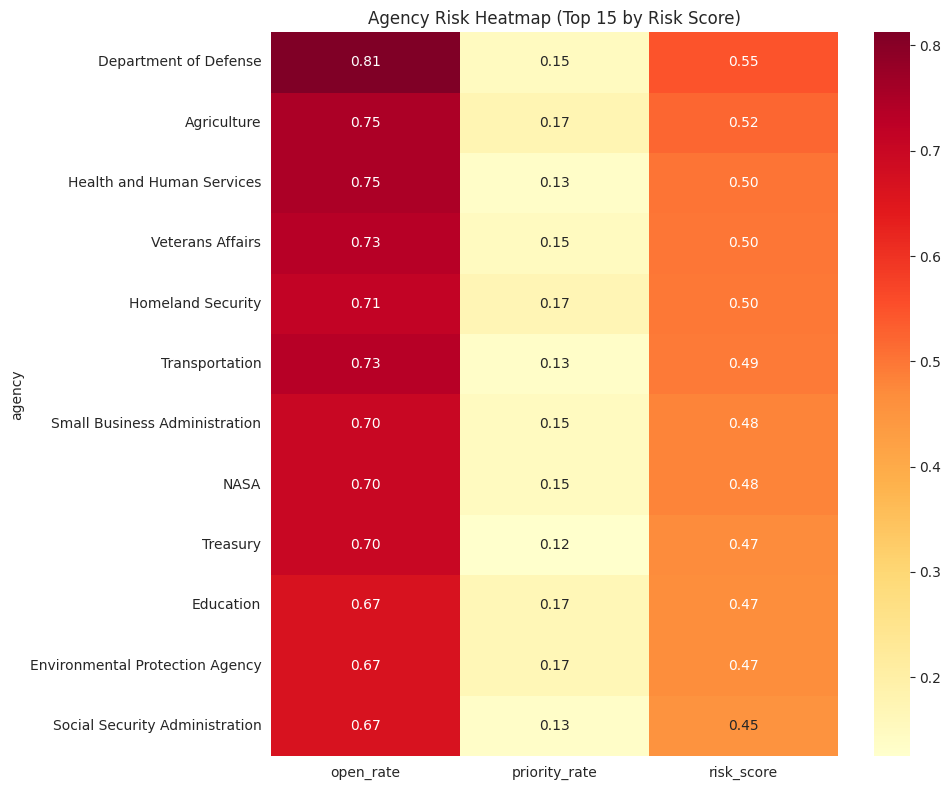

In [7]:
heatmap_data = agency_risk.set_index('agency')[['open_rate','priority_rate','risk_score']]
heatmap_data = heatmap_data.sort_values('risk_score', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Agency Risk Heatmap (Top 15 by Risk Score)')
plt.tight_layout()
plt.show()

## Save Results

In [8]:
results_df.to_csv('../data/risk_adjusted_forecasts.csv', index=False)
agency_risk.to_csv('../data/agency_risk_scores.csv', index=False)
print(f"Saved {len(results_df)} contract forecasts")
print(f"Saved {len(agency_risk)} agency risk scores")

NameError: name 'results_df' is not defined